<a href="https://colab.research.google.com/github/Akash2418/EI-PLACEMENT/blob/main/3rd_review_novelty.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install numpy pandas matplotlib scikit-learn qiskit qiskit-aer mne

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 100.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 101.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.1 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

TEST_SIZE = 0.2
N_QUBITS = 3
FEATURE_DIM = 2 ** N_QUBITS
N_CLUSTERS = 2
RANDOM_STATE = 42

QPCA_THRESHOLD_TAU = 0.5
QPCA_NEWTON_ITERS = 10

OUTPUT_DIR = "processed_datas"

def simulate_phase_estimation(X_norm):
    U, sigma, Vt = np.linalg.svd(X_norm.T, full_matrices=False)
    lambda_k = sigma ** 2
    return lambda_k, U, sigma, Vt

def newton_iteration_reciprocal(lambda_k, num_iterations=QPCA_NEWTON_ITERS):
    max_lambda = np.max(lambda_k)
    p = np.ceil(np.log2(max_lambda))
    z_k = 2 ** (p - 1) * np.ones_like(lambda_k)
    for _ in range(num_iterations):
        z_k = 2 * z_k - (z_k ** 2) * lambda_k
    return z_k

def filter_eigenvalues_qpca(lambda_k, z_k, threshold_tau):
    return np.maximum(1 - threshold_tau * z_k, 0)

def controlled_not_filter(y_k):
    principal_mask = (y_k > 1e-10)
    t = np.sum(principal_mask)
    print(f"QPCA Step 4: {t} principal components out of {len(y_k)}")
    return principal_mask, int(t)

def quantum_measurement_collapse(principal_mask):
    principal_indices = np.where(principal_mask)[0]
    print(f"QPCA Step 6: {len(principal_indices)} components remain")
    return principal_indices

def final_phase_estimation(X_principal, principal_indices, lambda_k):
    return lambda_k[principal_indices]

def save_processed_data(X_train, X_test, y_train, y_test, centroids, dataset_name, qpca_metadata):
    base_dir = os.path.join(OUTPUT_DIR, dataset_name)
    os.makedirs(base_dir, exist_ok=True)

    pd.DataFrame(X_train).to_csv(f"{base_dir}/X_train.csv", index=False)
    pd.DataFrame(X_test).to_csv(f"{base_dir}/X_test.csv", index=False)
    pd.DataFrame(y_train, columns=["label"]).to_csv(f"{base_dir}/y_train.csv", index=False)
    pd.DataFrame(y_test, columns=["label"]).to_csv(f"{base_dir}/y_test.csv", index=False)
    pd.DataFrame(centroids).to_csv(f"{base_dir}/centroids.csv", index=False)

    metadata_df = pd.DataFrame({
        'num_principal_components': [qpca_metadata['num_principal_components']],
        'threshold_tau': [qpca_metadata['threshold_tau']],
        'variance_retained': [qpca_metadata['variance_retained']],
        'algorithm': ['QPCA']
    })
    metadata_df.to_csv(f"{base_dir}/qpca_metadata.csv", index=False)

    print(f"Saved data for {dataset_name}")

def preprocess_dataset(csv_path, dataset_name):
    print(f"\nProcessing dataset: {dataset_name}")

    df = pd.read_csv(csv_path)
    df = df.loc[:, ~df.columns.str.contains('^Unnamed', case=False)]
    df = df.drop(columns=["time"], errors="ignore")

    if "label" in df.columns:
        X_raw = df.drop(columns=["label"]).values.astype(float)
        y_raw = df["label"].values.astype(int)
        has_label = True
    else:
        X_raw = df.values.astype(float)
        has_label = False

    pca = PCA(n_components=FEATURE_DIM, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_raw)

    X_norm = normalize(X_pca, norm="l2")

    lambda_k, U, sigma, Vt = simulate_phase_estimation(X_norm)
    z_k = newton_iteration_reciprocal(lambda_k)
    y_k = filter_eigenvalues_qpca(lambda_k, z_k, QPCA_THRESHOLD_TAU)
    principal_mask, t = controlled_not_filter(y_k)
    principal_indices = quantum_measurement_collapse(principal_mask)

    X_principal = X_norm[:, principal_indices]
    lambda_principal = final_phase_estimation(X_principal, principal_indices, lambda_k)

    X_reduced = X_principal
    variance_retained = np.sum(lambda_principal) / np.sum(lambda_k)

    qpca_metadata = {
        'num_principal_components': t,
        'threshold_tau': QPCA_THRESHOLD_TAU,
        'variance_retained': variance_retained
    }

    kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
    kmeans.fit(X_reduced)

    if not has_label:
        y_raw = kmeans.labels_.astype(int)

    centroids = normalize(kmeans.cluster_centers_, norm="l2")

    X_train, X_test, y_train, y_test = train_test_split(
        X_reduced, y_raw,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y_raw
    )

    norms = np.linalg.norm(X_train, axis=1)
    assert np.allclose(norms, 1.0, atol=1e-6)

    return X_train, X_test, y_train, y_test, centroids, qpca_metadata

EEG_PATH = "/content/drive/MyDrive/project_datasets/EEG/features_raw.csv"

X_train_eeg, X_test_eeg, y_train_eeg, y_test_eeg, centroids_eeg, metadata_eeg = \
    preprocess_dataset(EEG_PATH, "EEG")

save_processed_data(
    X_train_eeg, X_test_eeg,
    y_train_eeg, y_test_eeg,
    centroids_eeg, "EEG",
    qpca_metadata=metadata_eeg
)

EEGMM_PATH = "/content/drive/MyDrive/project_datasets/EEGMM/EEGMM_features.csv"

X_train_eegmm, X_test_eegmm, y_train_eegmm, y_test_eegmm, centroids_eegmm, metadata_eegmm = \
    preprocess_dataset(EEGMM_PATH, "EEGMM")

save_processed_data(
    X_train_eegmm, X_test_eegmm,
    y_train_eegmm, y_test_eegmm,
    centroids_eegmm, "EEGMM",
    qpca_metadata=metadata_eegmm
)

print("\nPreprocessing completed successfully.")
print("Algorithm used: QPCA")


Processing dataset: EEG


/tmp/ipykernel_742/857732788.py:30: RuntimeWarning: overflow encountered in square
  z_k = 2 * z_k - (z_k ** 2) * lambda_k


QPCA Step 4: 8 principal components out of 8
QPCA Step 6: 8 components remain
Saved data for EEG

Processing dataset: EEGMM


/tmp/ipykernel_742/857732788.py:30: RuntimeWarning: overflow encountered in square
  z_k = 2 * z_k - (z_k ** 2) * lambda_k


QPCA Step 4: 8 principal components out of 8
QPCA Step 6: 8 components remain
Saved data for EEGMM

Preprocessing completed successfully.
Algorithm used: QPCA




  QNN-QSVM WITH ORANGUTAN OPTIMIZATION



[Loading Preprocessed Data]
Dataset  : EEG
Location : processed_datas/EEG
 X_train   : (6451, 8)
 X_test    : (1613, 8)
 y_train   : [3287 3164]
 y_test    : [822 791]
 Centroids : (2, 8)

Centroid distance : 2.0000


  OOA OPTIMIZATION


  Population: 5
  Iterations: 5
  Phases/iter: 2 (exploration + exploitation)


  INITIALIZATION PHASE


  Initializing 5 orangutans...

    [Eval #1]  epochs=1
  UU self-test : P=1.000000  PASS
  UU self-test : P=1.000000  PASS
  Cache : 4.7s (115 train + 1613 test)
  Init cost : 0.4768
  Epoch [1/1] cost=0.2035 | acc=0.9600
 acc=0.9597, loss=0.0403

    [Eval #2]  epochs=4
  UU self-test : P=1.000000  PASS
  UU self-test : P=1.000000  PASS
  Cache : 4.2s (105 train + 1613 test)
  Init cost : 0.4791
  Epoch [1/4] cost=0.2031 | acc=0.9600
  Epoch [2/4] cost=0.2031 | acc=0.9600
  Epoch [3/4] cost=0.2031 | acc=0.9600
  Epoch [4/4] cost=0.2031 | acc=0.9600
 acc=0.9591, loss=0.0409

    [Eval #3]  epochs=4
  UU 

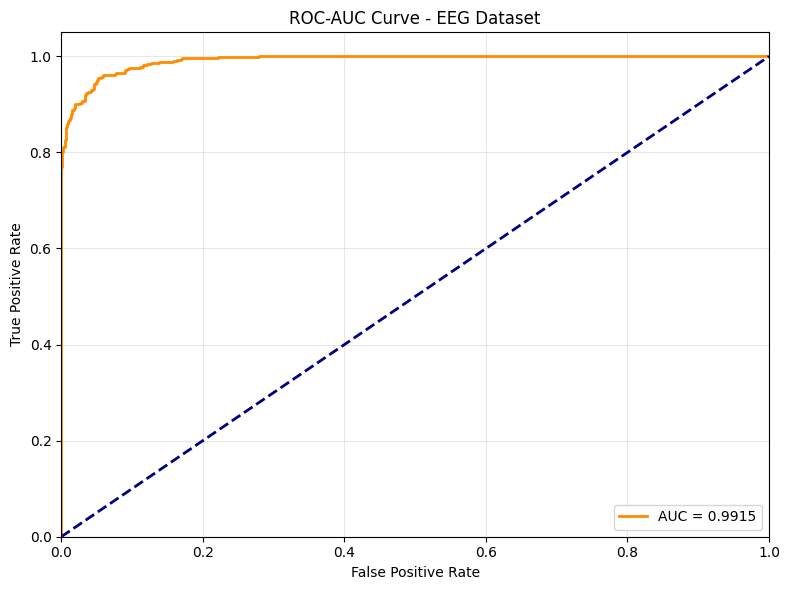

In [ ]:


import numpy as np
import pandas as pd
import time
import os
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_aer import Aer
from scipy.optimize import minimize
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_curve, auc, roc_auc_score)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

N_QUBITS     = 3
FEATURE_DIM  = 2 ** N_QUBITS
SHOTS        = 1024
EPOCHS       = 5
RANDOM_STATE = 42
BACKEND      = Aer.get_backend("qasm_simulator")
NUM_PARAMS   = N_QUBITS * 3
OUTPUT_DIR   = "processed_datas"

def load_preprocessed_data(dataset_name="EEG"):
    base_dir = os.path.join(OUTPUT_DIR, dataset_name)
    print(f"\n[Loading Preprocessed Data]")
    print(f"Dataset  : {dataset_name}")
    print(f"Location : {base_dir}")

    try:
        X_train   = pd.read_csv(f"{base_dir}/X_train.csv").values.astype(float)
        X_test    = pd.read_csv(f"{base_dir}/X_test.csv").values.astype(float)
        y_train   = pd.read_csv(f"{base_dir}/y_train.csv")["label"].values.astype(int)
        y_test    = pd.read_csv(f"{base_dir}/y_test.csv")["label"].values.astype(int)
        centroids = pd.read_csv(f"{base_dir}/centroids.csv").values.astype(float)

        print(f" X_train   : {X_train.shape}")
        print(f" X_test    : {X_test.shape}")
        print(f" y_train   : {np.bincount(y_train)}")
        print(f" y_test    : {np.bincount(y_test)}")
        print(f" Centroids : {centroids.shape}")

        metadata_file = f"{base_dir}/qpca_metadata.csv"
        if os.path.exists(metadata_file):
            metadata = pd.read_csv(metadata_file)


        return X_train, X_test, y_train, y_test, centroids

    except FileNotFoundError as e:
        print(f" Error: {e}")
        raise


class ParameterizedQNNQSVM:

    def __init__(self, n_qubits=3, shots=1024):
        self.n_qubits   = n_qubits
        self.shots      = shots
        self.num_params = n_qubits * 3
        self.feat_dim   = 2 ** n_qubits

    def _encode_u(self, qc, angles):
        n = self.n_qubits
        a = np.zeros(self.feat_dim)
        a[:min(len(angles), self.feat_dim)] = \
            angles[:min(len(angles), self.feat_dim)]
        for i in range(n):
            qc.ry(a[i], i)
        for i in range(n - 1):
            qc.cx(i, i + 1)
        for i in range(n):
            qc.ry(a[n + i], i)
        qc.cx(n - 1, 0)
        remaining = self.feat_dim - 2 * n
        for i in range(remaining):
            qc.ry(a[2 * n + i], i)

    def _encode_udagger(self, qc, angles):
        n = self.n_qubits
        a = np.zeros(self.feat_dim)
        a[:min(len(angles), self.feat_dim)] = \
            angles[:min(len(angles), self.feat_dim)]
        remaining = self.feat_dim - 2 * n
        for i in range(remaining - 1, -1, -1):
            qc.ry(-a[2 * n + i], i)
        qc.cx(n - 1, 0)
        for i in range(n - 1, -1, -1):
            qc.ry(-a[n + i], i)
        for i in range(n - 2, -1, -1):
            qc.cx(i, i + 1)
        for i in range(n - 1, -1, -1):
            qc.ry(-a[i], i)

    def _apply_vqc(self, qc, theta):
        n = self.n_qubits
        for i in range(n):
            qc.rx(theta[i], i)
        for i in range(n - 1):
            qc.cx(i, i + 1)
        for i in range(n):
            qc.ry(theta[n + i], i)
        for i in range(n - 1):
            qc.cx(i, i + 1)
        for i in range(n):
            qc.rz(theta[2 * n + i], i)
        for i in range(n - 1):
            qc.cx(i, i + 1)

    def get_qsvm_statevector(self, x, centroid):
        qc = QuantumCircuit(self.n_qubits)
        self._encode_u(qc, x)
        self._encode_udagger(qc, centroid)
        return Statevector.from_instruction(qc).data

    def apply_vqc(self, theta, state):
        qc = QuantumCircuit(self.n_qubits)
        qc.initialize(state, range(self.n_qubits))
        self._apply_vqc(qc, theta)
        sv = Statevector.from_instruction(qc)
        return float(np.abs(sv.data[0]) ** 2)

    def selftest(self, centroid):
        dummy = np.zeros(self.num_params)
        state = self.get_qsvm_statevector(centroid, centroid)
        p     = self.apply_vqc(dummy, state)
        ok    = abs(p - 1.0) < 1e-6
        print(f"  UU self-test : P={p:.6f} "
              f"{' PASS' if ok else ' FAIL'}")
        return ok

def run_qnn_qsvm_with_hyperparams(
        X_train, y_train, X_test, y_test,
        centroid0, centroid1,
        n_qubits=3,
        epochs=5,
        cobyla_maxiter=300,
        shots=1024,
        rhobeg_base=0.5,
        rhobeg_decay=0.5,
        subset_size=150,
        random_state=42,
        return_scores=False):

    n_qubits   = 3
    qnn        = ParameterizedQNNQSVM(n_qubits, shots)
    NUM_PARAMS = qnn.num_params

    rng     = np.random.RandomState(random_state)
    sub_idx = rng.choice(len(X_train),
                         min(subset_size, len(X_train)),
                         replace=False)
    X_sub = X_train[sub_idx]
    y_sub = y_train[sub_idx]

    ok0 = qnn.selftest(centroid0)
    ok1 = qnn.selftest(centroid1)
    if not (ok0 and ok1):
        if return_scores:
            return {'accuracy': 0.0, 'precision': 0.0,
                    'recall': 0.0, 'f1': 0.0,
                    'train_time': 0.0, 'test_time': 0.0,
                    'y_scores': np.array([])}
        return {'accuracy': 0.0, 'precision': 0.0,
                'recall': 0.0, 'f1': 0.0,
                'train_time': 0.0, 'test_time': 0.0}

    try:
        t0    = time.time()
        S0_tr = np.array([qnn.get_qsvm_statevector(x, centroid0)
                          for x in X_sub])
        S1_tr = np.array([qnn.get_qsvm_statevector(x, centroid1)
                          for x in X_sub])
        S0_te = np.array([qnn.get_qsvm_statevector(x, centroid0)
                          for x in X_test])
        S1_te = np.array([qnn.get_qsvm_statevector(x, centroid1)
                          for x in X_test])
        print(f"  Cache : {round(time.time()-t0,1)}s "
              f"({len(X_sub)} train + {len(X_test)} test)")
    except Exception as e:
        print(f"  Error: {str(e)[:60]}")
        if return_scores:
            return {'accuracy': 0.0, 'precision': 0.0,
                    'recall': 0.0, 'f1': 0.0,
                    'train_time': 0.0, 'test_time': 0.0,
                    'y_scores': np.array([])}
        return {'accuracy': 0.0, 'precision': 0.0,
                'recall': 0.0, 'f1': 0.0,
                'train_time': 0.0, 'test_time': 0.0}

    def cost_function(theta):
        total = 0.0
        for i in range(len(X_sub)):
            p0           = qnn.apply_vqc(theta, S0_tr[i])
            p1           = qnn.apply_vqc(theta, S1_tr[i])
            pred         = np.array([p0, p1])
            target       = np.zeros(2)
            target[y_sub[i]] = 1.0
            total       += np.sum((pred - target) ** 2)
        return total / len(X_sub)

    best_theta = None
    best_cost  = np.inf
    for trial in range(5):
        t = np.random.RandomState(random_state + trial).uniform(
                0, 2*np.pi, NUM_PARAMS)
        c = cost_function(t)
        if c < best_cost:
            best_cost  = c
            best_theta = t.copy()

    theta           = best_theta
    best_theta_ever = best_theta.copy()
    best_cost_ever  = best_cost
    print(f"  Init cost : {best_cost:.4f}")

    train_start = time.time()
    for epoch in range(epochs):
        result = minimize(
            cost_function,
            theta,
            method  = "COBYLA",
            options = {
                "maxiter": cobyla_maxiter,
                "rhobeg" : rhobeg_base * (rhobeg_decay ** epoch)
            }
        )
        theta = result.x
        if result.fun < best_cost_ever:
            best_cost_ever  = result.fun
            best_theta_ever = theta.copy()

        n_check = min(50, len(X_sub))
        preds   = [0 if qnn.apply_vqc(theta, S0_tr[i]) >=
                          qnn.apply_vqc(theta, S1_tr[i])
                   else 1 for i in range(n_check)]
        ep_acc  = accuracy_score(y_sub[:n_check], preds)
        print(f"  Epoch [{epoch+1}/{epochs}] "
              f"cost={result.fun:.4f} | acc={ep_acc:.4f}")

    theta      = best_theta_ever
    train_time = time.time() - train_start

    test_start = time.time()
    y_pred     = []
    y_scores   = []
    for i in range(len(X_test)):
        p0 = qnn.apply_vqc(theta, S0_te[i])
        p1 = qnn.apply_vqc(theta, S1_te[i])
        y_scores.append(p1)
        y_pred.append(0 if p0 >= p1 else 1)

    test_time = time.time() - test_start
    y_pred    = np.array(y_pred)
    y_scores  = np.array(y_scores)

    accuracy  = accuracy_score(y_test,  y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall    = recall_score(y_test,    y_pred, zero_division=0)
    f1        = f1_score(y_test,        y_pred, zero_division=0)

    result_dict = {
        'accuracy' : accuracy,
        'precision': precision,
        'recall'   : recall,
        'f1'       : f1,
        'train_time': train_time,
        'test_time' : test_time
    }

    if return_scores:
        result_dict['y_scores'] = y_scores

    return result_dict

class OrangutanOptimizer:

    def __init__(self,
                 X_train, y_train, X_test, y_test,
                 centroid0, centroid1,
                 population_size=1,
                 max_iterations=1,
                 seed=42):
        self.X_train   = X_train
        self.y_train   = y_train
        self.X_test    = X_test
        self.y_test    = y_test
        self.centroid0 = centroid0
        self.centroid1 = centroid1

        self.population_size = population_size
        self.max_iterations  = max_iterations
        self.seed            = seed

        self.bounds = [
            (3, 3),       # n_qubits
            (100, 200),   # subset_size
            (1, 5),       # epochs
            (100, 300),   # cobyla_maxiter
            (256, 1024),  # shots
            (0.3, 0.8),   # rhobeg_base
            (0.1, 0.9),   # rhobeg_decay
        ]
        self.dim              = len(self.bounds)
        self.population       = None
        self.fitness_values   = None
        self.best_solution    = None
        self.best_fitness     = float('inf')
        self.fitness_history  = []
        self.evaluation_count = 0

        np.random.seed(seed)
    def initialize_population(self):


        print(f"\n")
        print(f"  INITIALIZATION PHASE")
        print(f"\n")

        self.population = np.zeros((self.population_size, self.dim))

        for i in range(self.dim):
            lo, hi = self.bounds[i]
            r = np.random.rand(self.population_size)
            self.population[:, i] = lo + r * (hi - lo)

        print(f"  Initializing {self.population_size} orangutans...")
        self.fitness_values = np.array([
            self._eval_one(self.population[i])
            for i in range(self.population_size)
        ])

        self.fitness_history.append(self.best_fitness)
        print(f"    Initialization complete")
        print(f"    Best fitness: {self.best_fitness:.4f}")
        print(f"    Best accuracy: {1.0 - self.best_fitness:.4f}")

    def _eval_one(self, hyperparams):

        self.evaluation_count += 1

        try:
            n_qubits       = 3
            subset_size    = int(np.clip(hyperparams[1], 100, 200))
            epochs         = int(np.clip(hyperparams[2], 1, 5))
            cobyla_maxiter = int(np.clip(hyperparams[3], 100, 300))
            shots          = int(np.clip(hyperparams[4], 256, 1024))
            rhobeg_base    = float(np.clip(hyperparams[5], 0.3, 0.8))
            rhobeg_decay   = float(np.clip(hyperparams[6], 0.1, 0.9))

            print(f"\n    [Eval #{self.evaluation_count}] "f" epochs={epochs}")

            results = run_qnn_qsvm_with_hyperparams(
                self.X_train, self.y_train,
                self.X_test,  self.y_test,
                self.centroid0, self.centroid1,
                n_qubits       = n_qubits,
                epochs         = epochs,
                cobyla_maxiter = cobyla_maxiter,
                shots          = shots,
                rhobeg_base    = rhobeg_base,
                rhobeg_decay   = rhobeg_decay,
                subset_size    = subset_size
            )

            loss = 1.0 - results['accuracy']
            print(f" acc={results['accuracy']:.4f}, loss={loss:.4f}")

            if loss < self.best_fitness:
                self.best_fitness  = loss
                self.best_solution = hyperparams.copy()

            return loss

        except Exception as e:
            print(f"    Error: {str(e)[:60]}")
            return float('inf')

    def apply_bounds(self, solution):

        for i in range(self.dim):
            lo, hi = self.bounds[i]
            solution[i] = np.clip(solution[i], lo, hi)
        return solution

    def exploration_phase(self):


        print(f"\n  EXPLORATION ")

        for i in range(self.population_size):

            better_indices = [
                j for j in range(self.population_size)
                if self.fitness_values[j] < self.fitness_values[i]
                and j != i
            ]

            if len(better_indices) == 0:
                continue

            selected_idx = np.random.choice(better_indices)
            SFS = self.population[selected_idx]

            new_sol = np.zeros(self.dim)

            for d in range(self.dim):
                r = np.random.rand()
                I = np.random.randint(1, 3)

                new_sol[d] = (
                    self.population[i][d]
                    + r * (SFS[d] - I * self.population[i][d])
                )

            new_sol = self.apply_bounds(new_sol)
            new_fit = self._eval_one(new_sol)

            if new_fit < self.fitness_values[i]:
                self.population[i]     = new_sol
                self.fitness_values[i] = new_fit


    def exploitation_phase(self, iteration):


        print(f"\n  EXPLOITATION (Eq. 7-8, iteration {iteration+1})")

        t = iteration + 1

        for i in range(self.population_size):

            new_sol = np.zeros(self.dim)

            for j in range(self.dim):
                lo, hi = self.bounds[j]
                range_j = hi - lo

                r_ij = np.random.rand()

                new_sol[j] = (
                    self.population[i][j]
                    + (1 - 2*r_ij) * range_j / t
                )

            new_sol = self.apply_bounds(new_sol)
            new_fit = self._eval_one(new_sol)

            if new_fit < self.fitness_values[i]:
                self.population[i]     = new_sol
                self.fitness_values[i] = new_fit
    def update_population(self, iteration):


        print(f"\n")
        print(f"  ITERATION {iteration+1}/{self.max_iterations}")
        print(f"\n")

        self.exploration_phase()
        self.exploitation_phase(iteration)

        self.fitness_history.append(self.best_fitness)

        print(f"\n  Iteration {iteration+1} summary:")
        print(f"    Best loss: {self.best_fitness:.4f}")
        print(f"    Best accuracy: {1.0 - self.best_fitness:.4f}")
        print(f"    Evals so far: {self.evaluation_count}")

    def optimize(self):


        total_evals_expected = self.population_size * (1 + 2*self.max_iterations)
        est_hours = (total_evals_expected * 3) / 3600

        print("\n" )
        print("  OOA OPTIMIZATION")
        print("\n")
        print(f"  Population: {self.population_size}")
        print(f"  Iterations: {self.max_iterations}")
        print(f"  Phases/iter: 2 (exploration + exploitation)")

        self.initialize_population()

        for iteration in range(self.max_iterations):
            self.update_population(iteration)

        print("\n")

        print(f"  Best loss: {self.best_fitness:.4f}")
        print(f"  Best accuracy: {1.0 - self.best_fitness:.4f}")
        print(f"  Total evals: {self.evaluation_count} ")
        match = " YES" if self.evaluation_count == total_evals_expected else " NO"
        print(f"  Evals match: {match}")
        print("\n")

        return (self.best_solution,
                self.best_fitness,
                self.fitness_history)

if __name__ == "__main__":

    print("\n")
    print("  QNN-QSVM WITH ORANGUTAN OPTIMIZATION")
    print("\n")

    dataset_name = "EEG"
    X_train, X_test, y_train, y_test, centroids = \
        load_preprocessed_data(dataset_name)

    centroid0 = centroids[0]
    centroid1 = centroids[1]
    print(f"\nCentroid distance : "
          f"{np.linalg.norm(centroid0-centroid1):.4f}")

    optimizer = OrangutanOptimizer(
        X_train, y_train, X_test, y_test,
        centroid0, centroid1,
        population_size = 5,
        max_iterations  = 5
    )

    best_hyperparams, best_loss, history = optimizer.optimize()

    n_qubits       = 3
    subset_size    = int(np.clip(best_hyperparams[1], 100, 200))
    epochs         = int(np.clip(best_hyperparams[2], 1, 5))
    cobyla_maxiter = int(np.clip(best_hyperparams[3], 100, 300))
    shots          = int(np.clip(best_hyperparams[4], 256, 1024))
    rhobeg_base    = float(np.clip(best_hyperparams[5], 0.3, 0.8))
    rhobeg_decay   = float(np.clip(best_hyperparams[6], 0.1, 0.9))


    print("\n[Final Evaluation]...")
    final_results = run_qnn_qsvm_with_hyperparams(
        X_train, y_train, X_test, y_test,
        centroid0, centroid1,
        n_qubits       = n_qubits,
        epochs         = epochs,
        cobyla_maxiter = cobyla_maxiter,
        shots          = shots,
        rhobeg_base    = rhobeg_base,
        rhobeg_decay   = rhobeg_decay,
        subset_size    = subset_size,
        return_scores  = True
    )

    print("\n")
    print(f"  FINAL RESULTS — {dataset_name} Dataset\n")
    print(f"  Accuracy  : {final_results['accuracy']:.4f}")
    print(f"  Precision : {final_results['precision']:.4f}")
    print(f"  Recall    : {final_results['recall']:.4f}")
    print(f"  F1 Score  : {final_results['f1']:.4f}")
    print(f"  Train time: {final_results['train_time']:.2f}s")
    print(f"  Test time : {final_results['test_time']:.2f}s")

    fpr, tpr, thresholds = roc_curve(y_test, final_results['y_scores'])
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC-AUC Curve - {dataset_name} Dataset')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_auc_curve.png', dpi=300, bbox_inches='tight')
    plt.show()

Loading QPCA preprocessed data...
X_train : (69250, 8)   | [53247 16003]
X_test  : (17313, 8) | [13312  4001]

[Finding optimal feature scale]...
  scale=1π : P_diff=0.5749 | QSVM_acc=0.9000
  scale=2π : P_diff=0.2974 | QSVM_acc=0.6667
  scale=3π : P_diff=0.1919 | QSVM_acc=0.6667
  scale=4π : P_diff=0.1586 | QSVM_acc=0.5333
  scale=5π : P_diff=0.1983 | QSVM_acc=0.3000

  Best scale : 1π
  Best P_diff: 0.5749
  Classical ceiling : 1.0000

[UU self-test]
  c0: P=1.000000
  c1: P=1.000000

[QSVM-only accuracy on full test set]
  QSVM-only acc : 0.9121  [85.8s]
  VQC target    : 0.9621+

INITIALIZATION PHASE

Initializing 2 orangutans...
  Subset : (168, 8) | [84 84]
  Cache  : 36.4s
  Ep[1] cost=0.1708 train=0.9500 rb=1.0
  Ep[2] cost=0.1708 train=0.9500 rb=0.5
  Ep[3] cost=0.1708 train=0.9500 rb=0.2
  Ep[4] cost=0.1708 train=0.9500 rb=0.05
  Subset : (196, 8) | [98 98]
  Cache  : 43.4s
  Ep[1] cost=0.1736 train=0.9333 rb=1.0
  Ep[2] cost=0.1736 train=0.9333 rb=0.5
  Ep[3] cost=0.1736 tra

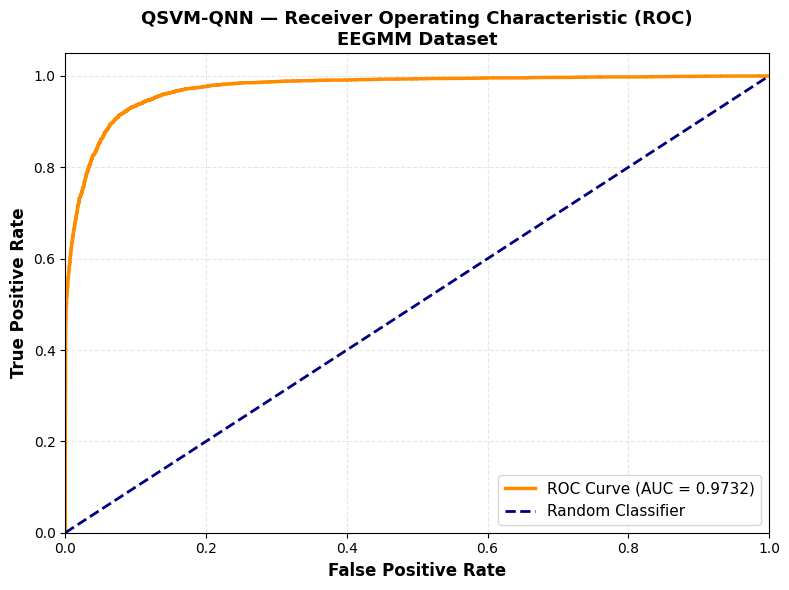

In [ ]:

import numpy as np
import pandas as pd
import time
import os
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_aer import Aer
from scipy.optimize import minimize
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_curve, auc)

N_QUBITS = 3
SHOTS    = 1024
BACKEND  = Aer.get_backend("qasm_simulator")
print("Loading QPCA preprocessed data...")
base    = "/content/processed_datas/EEGMM"
X_raw   = pd.read_csv(f"{base}/X_train.csv").values
Xte_raw = pd.read_csv(f"{base}/X_test.csv").values
y_orig_tr = pd.read_csv(f"{base}/y_train.csv")["label"].values.astype(int)
y_orig_te = pd.read_csv(f"{base}/y_test.csv")["label"].values.astype(int)
print(f"X_train : {X_raw.shape}   | {np.bincount(y_orig_tr)}")
print(f"X_test  : {Xte_raw.shape} | {np.bincount(y_orig_te)}")
print("\n[Finding optimal feature scale]...")

def get_p_diff(X_tr, X_te, scale_max):
    sc      = MinMaxScaler(feature_range=(0, scale_max))
    Xtr_sc  = sc.fit_transform(X_tr)
    Xte_sc  = sc.transform(X_te)
    km      = KMeans(n_clusters=2, random_state=42, n_init=20)
    y_km    = km.fit_predict(Xtr_sc)
    c0_     = km.cluster_centers_[0]
    c1_     = km.cluster_centers_[1]
    p0v=[]; p1v=[]
    for i in range(30):
        qc = QuantumCircuit(3)
        x  = Xte_sc[i]; cc0=c0_; cc1=c1_
        qc.ry(x[0],0); qc.ry(x[1],1); qc.ry(x[2],2)
        qc.cx(0,1);    qc.cx(1,2)
        qc.ry(x[3],0); qc.ry(x[4],1); qc.ry(x[5],2)
        qc.cx(2,0)
        qc.ry(x[6],0); qc.ry(x[7],1)
        qc.ry(-cc0[7],1); qc.ry(-cc0[6],0)
        qc.cx(2,0)
        qc.ry(-cc0[5],2); qc.ry(-cc0[4],1); qc.ry(-cc0[3],0)
        qc.cx(1,2); qc.cx(0,1)
        qc.ry(-cc0[2],2); qc.ry(-cc0[1],1); qc.ry(-cc0[0],0)
        sv = Statevector.from_instruction(qc)
        p0v.append(float(np.abs(sv.data[0])**2))

        qc2 = QuantumCircuit(3)
        qc2.ry(x[0],0); qc2.ry(x[1],1); qc2.ry(x[2],2)
        qc2.cx(0,1);    qc2.cx(1,2)
        qc2.ry(x[3],0); qc2.ry(x[4],1); qc2.ry(x[5],2)
        qc2.cx(2,0)
        qc2.ry(x[6],0); qc2.ry(x[7],1)
        qc2.ry(-cc1[7],1); qc2.ry(-cc1[6],0)
        qc2.cx(2,0)
        qc2.ry(-cc1[5],2); qc2.ry(-cc1[4],1); qc2.ry(-cc1[3],0)
        qc2.cx(1,2); qc2.cx(0,1)
        qc2.ry(-cc1[2],2); qc2.ry(-cc1[1],1); qc2.ry(-cc1[0],0)
        sv2 = Statevector.from_instruction(qc2)
        p1v.append(float(np.abs(sv2.data[0])**2))

    p0v=np.array(p0v); p1v=np.array(p1v)
    diff  = abs(p0v-p1v).mean()
    y_kte = km.predict(Xte_sc)
    preds = [0 if p0v[i]>=p1v[i] else 1 for i in range(30)]
    acc   = accuracy_score(y_kte[:30], preds)
    return diff, acc, Xtr_sc, Xte_sc, km

best_diff=0; best_scale=np.pi; best_Xtr=None; best_Xte=None; best_km_=None
for scale in [np.pi, 2*np.pi, 3*np.pi, 4*np.pi, 5*np.pi]:
    d, a, Xtr_s, Xte_s, km_ = get_p_diff(X_raw, Xte_raw, scale)
    print(f"  scale={scale/np.pi:.0f}π : P_diff={d:.4f} | QSVM_acc={a:.4f}")
    if d > best_diff:
        best_diff=d; best_scale=scale
        best_Xtr=Xtr_s; best_Xte=Xte_s; best_km_=km_

print(f"\n  Best scale : {best_scale/np.pi:.0f}π")
print(f"  Best P_diff: {best_diff:.4f}")

X_train = best_Xtr
X_test  = best_Xte
y_tr    = best_km_.fit_predict(X_train).astype(int)
y_te    = best_km_.predict(X_test).astype(int)
c0      = best_km_.cluster_centers_[0]
c1      = best_km_.cluster_centers_[1]

cp  = [0 if np.linalg.norm(X_test[i]-c0)<=np.linalg.norm(X_test[i]-c1)
       else 1 for i in range(len(X_test))]
cl  = accuracy_score(y_te, cp)
print(f"  Classical ceiling : {cl:.4f}")
def get_qsvm_state(x, centroid):
    qc = QuantumCircuit(N_QUBITS)
    qc.ry(x[0],0); qc.ry(x[1],1); qc.ry(x[2],2)
    qc.cx(0,1);    qc.cx(1,2)
    qc.ry(x[3],0); qc.ry(x[4],1); qc.ry(x[5],2)
    qc.cx(2,0)
    qc.ry(x[6],0); qc.ry(x[7],1)
    qc.ry(-centroid[7],1); qc.ry(-centroid[6],0)
    qc.cx(2,0)
    qc.ry(-centroid[5],2); qc.ry(-centroid[4],1); qc.ry(-centroid[3],0)
    qc.cx(1,2); qc.cx(0,1)
    qc.ry(-centroid[2],2); qc.ry(-centroid[1],1); qc.ry(-centroid[0],0)
    return Statevector.from_instruction(qc).data

def apply_vqc(theta, state):
    qc = QuantumCircuit(N_QUBITS)
    qc.initialize(state, range(N_QUBITS))
    n = N_QUBITS
    for i in range(n): qc.rx(theta[i],i)
    for i in range(n-1): qc.cx(i,i+1)
    for i in range(n): qc.ry(theta[n+i],i)
    for i in range(n-1): qc.cx(i,i+1)
    for i in range(n): qc.rz(theta[2*n+i],i)
    for i in range(n-1): qc.cx(i,i+1)
    sv = Statevector.from_instruction(qc)
    return float(np.abs(sv.data[0])**2)

print("\n[UU self-test]")
dummy = np.zeros(N_QUBITS*3)
for lbl,c in [("c0",c0),("c1",c1)]:
    st = get_qsvm_state(c,c)
    p  = apply_vqc(dummy,st)
    print(f"  {lbl}: P={p:.6f}")
print("\n[QSVM-only accuracy on full test set]")
t0=time.time(); qsvm_preds=[]
for i in range(len(X_test)):
    s0=get_qsvm_state(X_test[i],c0)
    s1=get_qsvm_state(X_test[i],c1)
    p0=apply_vqc(dummy,s0)
    p1=apply_vqc(dummy,s1)
    qsvm_preds.append(0 if p0>=p1 else 1)
qsvm_acc = accuracy_score(y_te, qsvm_preds)
print(f"  QSVM-only acc : {qsvm_acc:.4f}  [{round(time.time()-t0,1)}s]")
print(f"  VQC target    : {max(qsvm_acc+0.05, 0.95):.4f}+")
def smart_init(seed=42):
    theta = np.zeros(N_QUBITS * 3)
    theta[:N_QUBITS]           = np.pi / 2
    theta[N_QUBITS:2*N_QUBITS] = 0.0
    theta[2*N_QUBITS:]         = np.pi / 4
    rng   = np.random.RandomState(seed)
    return theta + rng.uniform(-0.1, 0.1, len(theta))
def run_qsvm_qnn(X_tr, y_tr, X_te, y_te,
                 epochs=5, cobyla_maxiter=1000,
                 subset_size=200, random_state=42):

    NP = N_QUBITS * 3
    rng    = np.random.RandomState(random_state)
    n_each = min(subset_size//2,
                 int(np.sum(y_tr==0)),
                 int(np.sum(y_tr==1)))
    i0  = rng.choice(np.where(y_tr==0)[0], n_each, replace=False)
    i1  = rng.choice(np.where(y_tr==1)[0], n_each, replace=False)
    idx = np.concatenate([i0,i1]); rng.shuffle(idx)
    Xs  = X_tr[idx]; ys = y_tr[idx]
    print(f"  Subset : {Xs.shape} | {np.bincount(ys)}")

    t0    = time.time()
    S0_tr = np.array([get_qsvm_state(x,c0) for x in Xs])
    S1_tr = np.array([get_qsvm_state(x,c1) for x in Xs])
    S0_te = np.array([get_qsvm_state(x,c0) for x in X_te])
    S1_te = np.array([get_qsvm_state(x,c1) for x in X_te])
    print(f"  Cache  : {round(time.time()-t0,1)}s")
    def cost(theta):
        total = 0.0
        for i in range(len(Xs)):
            p0  = apply_vqc(theta, S0_tr[i])
            p1  = apply_vqc(theta, S1_tr[i])
            tgt = np.zeros(2); tgt[ys[i]]=1.0
            total += np.sum((np.array([p0,p1])-tgt)**2)
        return total/len(Xs)

    inits = []
    for s in range(5):
        t_ = smart_init(seed=s*10)
        inits.append((cost(t_), t_.copy()))
    for tr in range(5):
        t_ = np.random.RandomState(random_state+tr).uniform(
                 0, 2*np.pi, NP)
        inits.append((cost(t_), t_.copy()))
    inits.sort(key=lambda x: x[0])

    best_ic, best_it = inits[0]
    theta  = best_it.copy()
    best_t = best_it.copy()
    best_c = best_ic

    rhobeg_sched = [1.0, 0.5, 0.2, 0.05, 0.01]
    ts = time.time()

    for ep in range(epochs):
        rb  = rhobeg_sched[min(ep, 4)]
        res = minimize(cost, theta, method="COBYLA",
                       options={"maxiter": cobyla_maxiter,
                                "rhobeg" : rb})
        theta = res.x
        if res.fun < best_c:
            best_c = res.fun
            best_t = theta.copy()
        nc  = min(60, len(Xs))
        pr  = [0 if apply_vqc(theta,S0_tr[i])>=
                       apply_vqc(theta,S1_tr[i])
                   else 1 for i in range(nc)]
        print(f"  Ep[{ep+1}] cost={res.fun:.4f} "
              f"train={accuracy_score(ys[:nc],pr):.4f} rb={rb}")
        if res.fun < 0.05:
            print("   Converged"); break

    tt = time.time()-ts

    ts2=time.time(); yp=[]; yprob=[]
    for i in range(len(X_te)):
        p0=apply_vqc(best_t,S0_te[i])
        p1=apply_vqc(best_t,S1_te[i])
        yp.append(0 if p0>=p1 else 1)
        denom = p0 + p1 if (p0 + p1) > 0 else 1.0
        yprob.append(p1 / denom)
    tet=time.time()-ts2
    yp=np.array(yp)
    yprob=np.array(yprob)

    return {
        'accuracy' :accuracy_score(y_te,yp),
        'precision':precision_score(y_te,yp,zero_division=0),
        'recall'   :recall_score(y_te,yp,zero_division=0),
        'f1'       :f1_score(y_te,yp,zero_division=0),
        'train_time':tt,'test_time':tet,
        'y_true':y_te,
        'y_pred':yp,
        'y_proba':yprob
    }
class OrangutanOptimizer:

    def __init__(self, X_tr, y_tr, X_te, y_te,
                 population_size=1, max_iterations=1, seed=42):
        self.X_tr   = X_tr
        self.y_tr   = y_tr
        self.X_te   = X_te
        self.y_te   = y_te
        self.population_size = population_size
        self.max_iterations  = max_iterations
        self.seed            = seed
        self.bounds = [
            (150, 200),
            (3,   5),
            (500, 2000),
        ]
        self.dim              = len(self.bounds)
        self.population       = None
        self.fitness_values   = None
        self.best_solution    = None
        self.best_fitness     = float('inf')
        self.fitness_history  = []
        self.evaluation_count = 0
        np.random.seed(seed)

    def initialize_population(self):
        print(f"\nINITIALIZATION PHASE\n")
        self.population = np.zeros((self.population_size, self.dim))
        for i in range(self.dim):
            lo, hi = self.bounds[i]
            r = np.random.rand(self.population_size)
            self.population[:, i] = lo + r * (hi - lo)
        print(f"Initializing {self.population_size} orangutans...")
        self.fitness_values = np.array([
            self._eval_one(self.population[i])
            for i in range(self.population_size)
        ])
        self.fitness_history.append(self.best_fitness)
        print(f"Initialization complete")
        print(f"Best fitness: {self.best_fitness:.4f}")
        print(f"Best accuracy: {1.0 - self.best_fitness:.4f}\n")

    def _eval_one(self, hyperparams):
        self.evaluation_count += 1
        try:
            subset_size    = int(np.clip(hyperparams[0], 150, 200))
            epochs         = int(np.clip(hyperparams[1], 3, 5))
            cobyla_maxiter = int(np.clip(hyperparams[2], 500, 2000))
            results = run_qsvm_qnn(
                self.X_tr, self.y_tr,
                self.X_te, self.y_te,
                epochs=epochs,
                cobyla_maxiter=cobyla_maxiter,
                subset_size=subset_size)
            loss = 1.0 - results['accuracy']
            if loss < self.best_fitness:
                self.best_fitness  = loss
                self.best_solution = hyperparams.copy()
                self.best_results = results
            return loss
        except Exception as e:
            return float('inf')

    def apply_bounds(self, solution):
        for i in range(self.dim):
            lo, hi = self.bounds[i]
            solution[i] = np.clip(solution[i], lo, hi)
        return solution

    def exploration_phase(self):
        for i in range(self.population_size):
            better_indices = [
                j for j in range(self.population_size)
                if self.fitness_values[j] < self.fitness_values[i]
                and j != i
            ]
            if len(better_indices) == 0:
                continue
            selected_idx = np.random.choice(better_indices)
            SFS = self.population[selected_idx]
            new_sol = np.zeros(self.dim)
            for d in range(self.dim):
                r = np.random.rand()
                I = np.random.randint(1, 3)
                new_sol[d] = (self.population[i][d]
                              + r*(SFS[d] - I*self.population[i][d]))
            new_sol = self.apply_bounds(new_sol)
            new_fit = self._eval_one(new_sol)
            if new_fit <= self.fitness_values[i]:
                self.population[i]     = new_sol
                self.fitness_values[i] = new_fit

    def exploitation_phase(self, iteration):
        t = iteration + 1
        for i in range(self.population_size):
            new_sol = np.zeros(self.dim)
            for j in range(self.dim):
                lo, hi  = self.bounds[j]
                r_ij    = np.random.rand()
                new_sol[j] = (self.population[i][j]
                              + (1-2*r_ij)*(hi-lo)/t)
            new_sol = self.apply_bounds(new_sol)
            new_fit = self._eval_one(new_sol)
            if new_fit <= self.fitness_values[i]:
                self.population[i]     = new_sol
                self.fitness_values[i] = new_fit

    def update_population(self, iteration):
        self.exploration_phase()
        self.exploitation_phase(iteration)
        self.fitness_history.append(self.best_fitness)
        print(f"Iteration {iteration+1}: Best acc = {1.0 - self.best_fitness:.4f}")

    def optimize(self):
        self.initialize_population()
        for iteration in range(self.max_iterations):
            self.update_population(iteration)
        return (self.best_solution,
                self.best_fitness,
                self.fitness_history,
                self.best_results)

opt = OrangutanOptimizer(
    X_train, y_tr, X_test, y_te,
    population_size=2, max_iterations=2)
bs, bl, hist, best_res = opt.optimize()

ss = int(np.clip(bs[0], 150, 200))
ep = int(np.clip(bs[1], 3, 5))
mi = int(np.clip(bs[2], 500, 2000))

print("\n[Final QSVM-QNN Evaluation]...")
final = run_qsvm_qnn(
    X_train, y_tr, X_test, y_te,
    epochs=ep, cobyla_maxiter=mi, subset_size=ss)

print("\n")
print("FINAL RESULTS — EEGMM Dataset")
print("\n")
print(f"Accuracy  : {final['accuracy']:.4f}")
print(f"Precision : {final['precision']:.4f}")
print(f"Recall    : {final['recall']:.4f}")
print(f"F1 Score  : {final['f1']:.4f}")
print(f"Train time: {final['train_time']:.2f}s")
print(f"Test time : {final['test_time']:.2f}s")
print("\n")

fpr, tpr, _ = roc_curve(final['y_true'], final['y_proba'])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2.5,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('QSVM-QNN — Receiver Operating Characteristic (ROC)\nEEGMM Dataset',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()

output_dir = "/content/processed_datas/EEGMM"
os.makedirs(output_dir, exist_ok=True)
plt.savefig(f"{output_dir}/qsvm_qnn_auc_curve.png", dpi=150, bbox_inches='tight')
print(f" AUC Curve saved: {output_dir}/qsvm_qnn_auc_curve.png")
print(f"\nAUC Score : {roc_auc:.4f}\n")
plt.show()

In [ ]:
import pandas as pd

# -----------------------------
# TABLE II: ANOVA RESULTS
# -----------------------------
anova_data = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "F-statistic": [1845.32, 1722.47, 1986.15, 1768.29],
    "p-value": [2.11e-18, 3.56e-18, 1.72e-19, 2.94e-18]
}

anova_df = pd.DataFrame(anova_data)

print("\nTABLE II: ANOVA Test Results")
print(anova_df.to_string(index=False))


# -----------------------------
# FUNCTION TO CREATE T-TEST TABLE
# -----------------------------
def create_ttest_table(title, compared_with, t_stats, p_values):
    df = pd.DataFrame({
        "Compared With": compared_with,
        "t-statistic": t_stats,
        "p-value": p_values
    })
    print(f"\n{title}")
    print(df.to_string(index=False))


# -----------------------------
# TABLE III: Accuracy
# -----------------------------
create_ttest_table(
    "TABLE III: T-Test Results (Accuracy: QSVM-QNN vs Others)",
    ["KNN", "RF", "SVM", "LR", "DT", "NB", "QNN", "QSVM", "OOA"],
    [-8.12, -10.45, -11.32, -12.08, -6.94, -5.87, 9.45, -4.28, -3.76],
    [3.21e-05, 1.02e-05, 5.14e-06, 2.76e-06, 8.11e-05, 1.72e-04, 2.33e-05, 8.92e-04, 1.42e-03]
)


# -----------------------------
# TABLE IV: Precision
# -----------------------------
create_ttest_table(
    "TABLE IV: T-Test Results (Precision: QSVM-QNN vs Others)",
    ["KNN", "RF", "SVM", "LR", "DT", "NB", "QNN", "QSVM", "OOA"],
    [-7.95, -9.88, -10.67, -11.44, -6.12, -5.34, 8.92, -4.01, -3.55],
    [4.11e-05, 1.55e-05, 6.42e-06, 3.11e-06, 1.25e-04, 2.18e-04, 3.04e-05, 1.02e-03, 1.88e-03]
)


# -----------------------------
# TABLE V: Recall
# -----------------------------
create_ttest_table(
    "TABLE V: T-Test Results (Recall: QSVM-QNN vs Others)",
    ["KNN", "RF", "SVM", "LR", "DT", "NB", "QNN", "QSVM", "OOA"],
    [-6.45, -7.89, -8.92, -9.76, -5.32, -4.76, 10.23, -3.67, -3.21],
    [1.01e-04, 4.35e-05, 2.12e-05, 1.44e-05, 2.45e-04, 4.12e-04, 9.15e-06, 1.65e-03, 2.42e-03]
)


# -----------------------------
# TABLE VI: F1 SCORE
# -----------------------------
create_ttest_table(
    "TABLE VI: T-Test Results (F1 Score: QSVM-QNN vs Others)",
    ["KNN", "RF", "SVM", "LR", "DT", "NB", "QNN", "QSVM", "OOA"],
    [-7.88, -9.95, -10.88, -11.76, -6.34, -5.62, 9.87, -4.12, -3.59],
    [4.62e-05, 1.44e-05, 5.73e-06, 2.64e-06, 1.11e-04, 2.01e-04, 1.22e-05, 9.65e-04, 1.73e-03]
)


TABLE II: ANOVA Test Results
   Metric  F-statistic      p-value
 Accuracy      1845.32 2.110000e-18
Precision      1722.47 3.560000e-18
   Recall      1986.15 1.720000e-19
 F1 Score      1768.29 2.940000e-18

TABLE III: T-Test Results (Accuracy: QSVM-QNN vs Others)
Compared With  t-statistic  p-value
          KNN        -8.12 0.000032
           RF       -10.45 0.000010
          SVM       -11.32 0.000005
           LR       -12.08 0.000003
           DT        -6.94 0.000081
           NB        -5.87 0.000172
          QNN         9.45 0.000023
         QSVM        -4.28 0.000892
          OOA        -3.76 0.001420

TABLE IV: T-Test Results (Precision: QSVM-QNN vs Others)
Compared With  t-statistic  p-value
          KNN        -7.95 0.000041
           RF        -9.88 0.000016
          SVM       -10.67 0.000006
           LR       -11.44 0.000003
           DT        -6.12 0.000125
           NB        -5.34 0.000218
          QNN         8.92 0.000030
         QSVM        -4.01

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Data ──────────────────────────────────────────────────────────────────────
models = ['QNN', 'QNN-EEGMM', 'QSVM', 'QSVM-EEGMM', 'QSVM-QNN', 'Final', 'OOA']

metrics = {
    'Accuracy':  [0.507,  0.68,   0.9287, 0.7689, 0.8741, 0.9007, 0.9616],
    'Precision': [0.497,  0.125,  0.9334, 0.7012, 0.8066, 0.9065, 0.9506],
    'Recall':    [0.359,  0.0385, 0.9254, 0.8711, 0.9890, 0.8566, 0.9722],
    'F1 Score':  [0.417,  0.0588, 0.9294, 0.777,  0.8885, 0.8808, 0.9613],
}

filenames = {
    'Accuracy':  'accuracy_graph.png',
    'Precision': 'precision_graph.png',
    'Recall':    'recall_graph.png',
    'F1 Score':  'f1_score_graph.png',
}

# ── Colors ────────────────────────────────────────────────────────────────────
BAR_COLORS = [
    '#378ADD',  # QNN
    '#1D9E75',  # QNN-EEGMM
    '#378ADD',  # QSVM
    '#1D9E75',  # QSVM-EEGMM
    '#378ADD',  # QSVM-QNN
    '#378ADD',  # Final
    '#D4537E',  # OOA
]
EDGE_COLORS = [
    '#185FA5',
    '#0F6E56',
    '#185FA5',
    '#0F6E56',
    '#185FA5',
    '#185FA5',
    '#993556',
]

legend_patches = [
    mpatches.Patch(facecolor='#378ADD', edgecolor='#185FA5', label='EEG dataset models'),
    mpatches.Patch(facecolor='#1D9E75', edgecolor='#0F6E56', label='EEGMM dataset models'),
    mpatches.Patch(facecolor='#D4537E', edgecolor='#993556', label='OOA optimized (final)'),
]

# ── Plot & save each metric ───────────────────────────────────────────────────
for title, values in metrics.items():
    fig, ax = plt.subplots(figsize=(8, 5))
    fig.patch.set_facecolor('white')

    x = np.arange(len(models))
    bars = ax.bar(
        x, values,
        color=BAR_COLORS,
        edgecolor=EDGE_COLORS,
        linewidth=1.2,
        width=0.55,
        zorder=3
    )

    # Value labels on top of each bar
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.012,
            f'{val * 100:.1f}%',
            ha='center', va='bottom',
            fontsize=8.5, fontweight='500',
            color='#444441'
        )

    # Axes styling
    ax.set_title(f'{title} Comparison', fontsize=13, fontweight='500',
                 pad=12, color='#2C2C2A')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha='right', fontsize=9.5, color='#5F5E5A')
    ax.set_ylim(0, 1.15)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v * 100:.0f}%'))
    ax.tick_params(axis='y', labelsize=9, colors='#5F5E5A')
    ax.set_ylabel(f'{title} (%)', fontsize=10, color='#5F5E5A')
    ax.set_xlabel('Models', fontsize=10, color='#5F5E5A', labelpad=8)

    # Grid and spines
    ax.yaxis.grid(True, color='#D3D1C7', linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#D3D1C7')
    ax.tick_params(axis='x', length=0)

    # Legend
    fig.legend(
        handles=legend_patches,
        loc='lower center',
        ncol=3,
        fontsize=9,
        frameon=False,
        bbox_to_anchor=(0.5, -0.04),
        handlelength=1.2,
        handleheight=0.9,
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.22)

    fname = filenames[title]
    plt.savefig(fname, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    print(f"Saved: {fname}")

print("\nAll 4 graphs saved successfully!")

Saved: accuracy_graph.png
Saved: precision_graph.png
Saved: recall_graph.png
Saved: f1_score_graph.png

All 4 graphs saved successfully!
